<h1 align = 'center'> Principal Component Analysis </h1>

In this project we will implement the Principal Component Analysis and reduce the dimensions of the FashionMNIST Dataset. We will vizualize the data, classify using Kmeans and Nearest Centroid Classifier.

In [204]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import os
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score, ConfusionMatrixDisplay, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Functions

### Load Dataset

In [205]:
def load_dataset() -> tuple :
    """
    Load the fashionMNIST dataset
    """
    
    fashion_mnist = tf.keras.datasets.fashion_mnist
    return fashion_mnist.load_data()

### Flattening

In [206]:
def flattening(X):
    """
    flat the 28x28 image to a 784 vector

    Args:
        X (_type_): the images set
    """

    return X.reshape(X.shape[0], -1)

### Evaluation

In [207]:
def evaluation(y_pred,y_true):
    """
    Print an evaluation report using the metrics accuracy,macro precision

    Args:
        y_pred (_np.ndarray): the labels the model predicted
        y_true (np.ndarray): the real labels
    """
    # Confusion Matrix
    cm = confusion_matrix(y_true,y_pred)
    display = ConfusionMatrixDisplay(confusion_matrix=cm)
    acc = accuracy_score(y_true,y_pred)
    macro_pre = precision_score(y_true,y_pred, average='macro')
    print(f" Accuracy Score: {acc}")
    print(f" Recall per class: {recall_score(y_true,y_pred,average=None)}")
    print(f" Precision per class: {precision_score(y_true,y_pred,average=None)}")
    print(f" Macro Precision: {macro_pre}")

    display.plot()
    plt.show()

    return acc, macro_pre

In [208]:
def plot_and_save_analysis(y_true, y_pred, x_test_images, model_name):
    """
    Create the confusion matrix and plot some True-False preidctions.
    """
   
    output_dir = f"analysis_{model_name.replace(' ', '_')}"
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    
    cm_filename = os.path.join(output_dir, "confusion_matrix1.svg")
    plt.savefig(cm_filename, format='svg', bbox_inches='tight')
    plt.close()

    correct_indices = np.where(y_true == y_pred)[0]
    wrong_6_as_0 = np.where((y_true == 6) & (y_pred == 4))[0]
    wrong_4_as_2 = np.where((y_true == 6) & (y_pred == 4))[0]

    correct_indices = np.where(y_true == y_pred)[0]
    wrong_6_as_0 = np.where((y_true == 4) & (y_pred == 2))[0]
    wrong_4_as_2 = np.where((y_true == 4) & (y_pred == 2))[0]

    
    if len(correct_indices) >= 2:
        
        c1, c2 = np.random.choice(correct_indices, 2, replace=False)
        
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        fig.suptitle(f'True Predictions - {model_name}', fontsize=14)

        axes[0].imshow(x_test_images[c1].reshape(28, 28), cmap='gray')
        axes[0].set_title(f"True: {y_true[c1]} | Pred: {y_pred[c1]}")
        axes[0].axis('off')
        
        axes[1].imshow(x_test_images[c2].reshape(28, 28), cmap='gray')
        axes[1].set_title(f"True: {y_true[c2]} | Pred: {y_pred[c2]}")
        axes[1].axis('off')

        correct_filename = os.path.join(output_dir, "correct_examples1.svg")
        plt.savefig(correct_filename, format='svg', bbox_inches='tight')
        plt.show() 
        

    
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    fig.suptitle(f'False Predictions - {model_name}', fontsize=14)

    if len(wrong_6_as_0) > 0:
        w1 = np.random.choice(wrong_6_as_0)
        axes[0].imshow(x_test_images[w1].reshape(28, 28), cmap='gray')
        axes[0].set_title(f"True: 7 | Pred: 1")
        axes[0].axis('off')
    else:
        axes[0].text(0.5, 0.5, "Not Found\nTrue=6, Pred=0!", ha='center')
        axes[0].axis('off')

    if len(wrong_4_as_2) > 0:
        w2 = np.random.choice(wrong_4_as_2)
        axes[1].imshow(x_test_images[w2].reshape(28, 28), cmap='gray')
        axes[1].set_title(f"True: 4  | Pred: 9 ")
        axes[1].axis('off')
    else:
        axes[1].text(0.5, 0.5, "NOt Found\nTrue=4, Pred=2!", ha='center')
        axes[1].axis('off')

    wrong_filename = os.path.join(output_dir, "wrong_examples1.svg")
    plt.savefig(wrong_filename, format='svg', bbox_inches='tight')
    plt.show() 


# Classes 

Even if PCA tries to maximize the projected Variance , we will prove that we dont need training using loops but we can find the subspace using a close formula.

Our goal is to find a vector $u$ in which the projected variance of the samples are maximized. We know that $ Variance = u^T\Sigma u$

Lets write it as an optimization problem: Maximize $f = u^T\Sigma u$

However we could make $u$ infinite big and the variance would also go to infinity. So to avoid this we want to find $u$ where $u$ is a unit vector, $u^T u = 1$

So the problem now is: Maximize $f(u) = u^T\Sigma u$   subject to $g(u) = u^T u = 1$

According to the constraint optimization to solve this problem we need the lagrance function and the lagrance multipliers
$L(u, \lambda ) = f(u) - \lambda g(u)$

To find a critical point, a possible u that solves the problem we must set $\nabla L = 0 => 2\Sigma u - 2\lambda u = 0 => \Sigma u = \lambda u$ which is the eigendecomposition in linear algebra.

If we use this equation in the original formula of variance we have: $Variance = u^T ( \Sigma u) = u^T ( \lambda u) = \lambda (u^T u)$

Before we set $u^T u = 1$ so $Variance = \lambda$

In conclusion the projected Variance on the axes $u$ equals to eigenvalue $\lambda$. So to maximize the variance we must calculate the eigenvectors of $\Sigma$ and select the eigenvector that corresponds to the biggest eigenvalue $\lambda$

In [209]:
class PCA_custom:
    def __init__(self,K):
        self.K = K
        self.mean_vector = None
        self.U = None

    def fit(self,X):
        N,D = X.shape

        # Calculate the mean vector for each dimension
        self.mean_vector = np.mean(X, axis=0)

        # Center the Data
        X_centered = X - self.mean_vector

        # Calculate the Covariance Matrix
        # S  = 1/N * (X - columns_mean.T).T @ (X - columns_mean.T)
        S = (X_centered.T @ X_centered)/N

        # Eigendecomposition (Calculate eigenvectors and eigenvalues)
        eigenvalues, eigenvectors = np.linalg.eigh(S)

        # eigh return the eigenvalues in ascending order
        sorted_indices = np.argsort(eigenvalues)[::-1]
        top_k_indices = sorted_indices[:self.K]

        # Create the matrix U with the principal components
        self.U = eigenvectors[:, top_k_indices]

    def transform(self,X):

        # Center the matrix
        X = X - self.mean_vector

        # Project X in the principal components subspace
        return X @ self.U
    
    def reconstruct(self,Z):
        return self.mean_vector + (Z @ self.U.T)  

In [ ]:
class Kmeans_c:
    def __init__(self,K):
        self.K = K
        self.means = None
        self.assignments = None

    def fit(self, X, max_iter=100):
        N, D = X.shape

        # Randomly Choose K points as the first means
        self.means = X[np.random.choice(N, self.K, replace=False)]

        # Training Loop
        for i in range(max_iter):

            # Find the euclidean distances for each point from each center
            distances = np.array([[np.linalg.norm(x-m) for m in self.means] for x in X])

            # Assign each point to the nearest Center
            self.assignments = np.argmin(distances,axis=1)

            # Update the Centers
            new_means = np.zeros((self.K,D))
            for k in range(self.K):
                # Keep the points of each center
                points = X[self.assignments == k]

                if len(points)==0:
                    # If a center has no points we keep it as is 
                    new_means[k] = self.means[k]
                else:
                    # The new Center is the mean of points
                    new_means[k] = np.mean(points,axis=0)

            if np.all(self.means == new_means):
                breakArchetype 
            self.means = new_means

    def return_means_assignments(self):
        return self.means, self.assignments
    
    def predict(self,X):
        distances = np.array([[np.linalg.norm(x-m) for m in self.means] for x in X])
        return np.argmin(distances,axis=1)


In [211]:
def mahalanobis(x,m,inv_s):
    return (x-m).T @ inv_s @ (x-m)


In [212]:
class NearestCentroid:
    def __init__(self,n_subclasses,metric):
        self.n_subclasses = n_subclasses
        self.metric = metric
        self.centers = {}
        self.inverse_cov_matrixes = {}
        self.parent_class = {}
    
    def fit(self,X,y):
        classes = np.unique(y)
        subclass = 0

        for c in classes:

            # Extract the classes data
            class_X = X[y==c]

            # Use Kmeans if we want subclasses
            if self.n_subclasses>1:
                kmeans = KMeans(n_clusters=self.n_subclasses)
                sub_assignments = kmeans.fit_predict(class_X)
            else:
                # if we dont want subclasses then all samples belong to subclass 0
                sub_assignments = np.zeros(len(class_X))

            for k in range(self.n_subclasses):
                subclass_X = class_X[sub_assignments==k]
                
                # Calculate the center
                center = np.mean(subclass_X, axis=0)

                # Covariance Matrix
                cov_matrix = np.cov(subclass_X, rowvar=False)

                # Calculate inverse
                inv_cov_matrix = np.linalg.inv(cov_matrix)

                self.centers[subclass] = center
                self.inverse_cov_matrixes[subclass]= inv_cov_matrix
                self.parent_class[subclass] = c

                subclass+=1
        
    def predict(self, X):

        preds = []
        subclasses = list(self.centers.keys())

        for x in X:
            distances = []
            for subclass in subclasses:
                 # Calculate the mahalanobis or Euclidean distance for class-subclass center
                if self.metric == 'mahalanobis':
                     dist = mahalanobis(x,self.centers[subclass],self.inverse_cov_matrixes[subclass])
                else:
                    dist = np.linalg.norm(x - self.centers[subclass])
                distances.append(dist)
            # Find the nearest subclass
            nearest_subclass = subclasses[np.argmin(distances)]

            preds.append(self.parent_class[nearest_subclass])

        return np.array(preds)

# Main

## Load the Dataset

In [213]:
(x_train, y_train), (x_test,y_test) = load_dataset()

print(f"Training set shape: {x_train.shape}")
print(f"Test set shape: {x_test.shape}")
print(f"Training Labels shape: {y_train.shape}")
print(f"Test Labels shape: {y_test.shape}")

Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)
Training Labels shape: (60000,)
Test Labels shape: (10000,)


For 3 classes we keep 1000 samples

In [214]:
classes_to_keep = [0,6,7]
samples_per_classes = 1000

# Find the first 1000 indices for each class and concatenate
indices_train = np.concatenate([np.where(y_train==c)[0][:samples_per_classes] for c in classes_to_keep])
indices_test = np.concatenate([np.where(y_test==c)[0] for c in classes_to_keep])
X_train = x_train[indices_train]
Y_train = y_train[indices_train]
X_test = x_test[indices_test]
Y_test = y_test[indices_test]

X_train = flattening(X_train)
X_test = flattening(X_test)

print(X_train.shape)
print(Y_train.shape)

(3000, 784)
(3000,)


## Use PCA for dimensionality Reduction and Plotting

In [215]:
pca_for_plot = PCA_custom(K=3)
pca_for_plot.fit(X_train)
x_train_for_plot = pca_for_plot.transform(X_train)

df = pd.DataFrame(x_train_for_plot, columns=['D1' , 'D2' , 'D3'])
df['class'] = Y_train.astype(str)

fig = px.scatter_3d(df,x='D1',y='D2',z='D3',color='class', color_discrete_sequence=px.colors.qualitative.Set1,title="3D PCA Visualization",opacity=0.7,size_max=3)
fig.update_traces(marker = dict(size=3))
fig.show()

## Use Kmeans to the dimensionality reduced Data

In [216]:
K_means = Kmeans_c(K=3)
K_means.fit(x_train_for_plot,max_iter=1000)
means , assignments = K_means.return_means_assignments()

In [217]:
df_kmeans = pd.DataFrame({
    'D1': x_train_for_plot[:, 0],
    'D2': x_train_for_plot[:, 1],
    'D3': x_train_for_plot[:, 2],
    'Cluster': assignments.astype(str)
})

df_true = pd.DataFrame({
    'D1': x_train_for_plot[:, 0],
    'D2': x_train_for_plot[:, 1],
    'D3': x_train_for_plot[:, 2],
    'True_Label': Y_train.astype(str)
})


fig1 = px.scatter_3d(df_kmeans, x='D1', y='D2', z='D3', 
                     color='Cluster', opacity=0.4, 
                     title='Kmeans Centers')


fig1.update_traces(marker=dict(size=3)) 


fig1.add_trace(go.Scatter3d(
    x=means[:, 0], 
    y=means[:, 1], 
    z=means[:, 2],
    mode='markers',
    marker=dict(
        size=8,            
        color='black',       
        symbol='x', 
        opacity=1.0,         
        line=dict(width=1, color='black') 
    ),
    name='Κέντρα K-Means'
))

fig2 = px.scatter_3d(df_true, x='D1', y='D2', z='D3', 
                     color='True_Label', opacity=0.7,
                     title='True Labels')

fig1.show()
fig2.show()

### Evaluation

In [218]:
ari = adjusted_rand_score(Y_train,assignments)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")

Adjusted Rand Index (ARI): 0.4961


## Reconstruct and plot

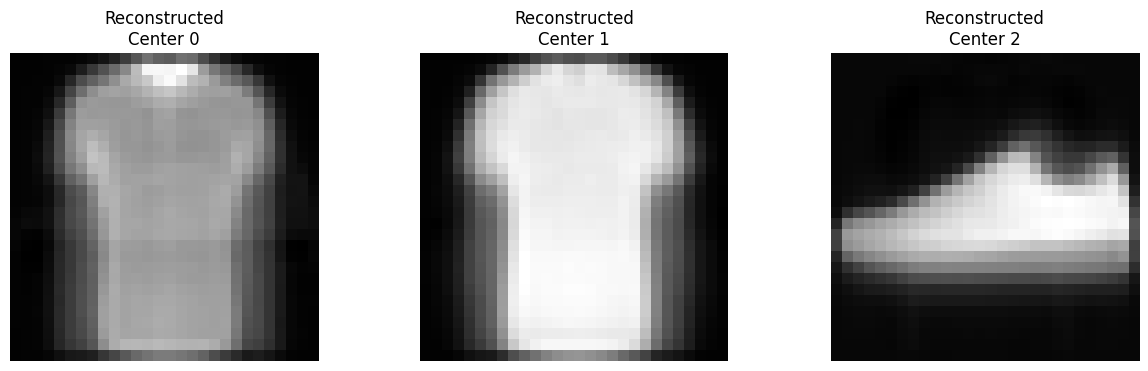

In [219]:
reconstructed_centers = pca_for_plot.reconstruct(Z=means)
K = reconstructed_centers.shape[0]

fig, axes = plt.subplots(1, K, figsize=(15, 4))
for i in range(K):
    center_image = reconstructed_centers[i].reshape(28, 28) 
    
    axes[i].imshow(center_image, cmap='gray')
    axes[i].set_title(f'Reconstructed\nCenter {i}')
    axes[i].axis('off')

plt.show()


## PCA and Mahalanobis

In [224]:
x_train = flattening(x_train)
x_test = flattening(x_test)

In [225]:
pca = PCA(n_components=10, random_state=42)
pca.fit(x_train)
x_train_transformed = pca.transform(x_train)
x_test_transformed = pca.transform(x_test)

## Mahalanobis Centroid Classifier using 1 subclass

 Accuracy Score: 0.7505
 Recall per class: [0.741 0.883 0.651 0.754 0.551 0.921 0.439 0.694 0.949 0.922]
 Precision per class: [0.73366337 0.99774011 0.56855895 0.77096115 0.63921114 0.7974026
 0.42621359 0.946794   0.85265049 0.8466483 ]
 Macro Precision: 0.7579843695642052


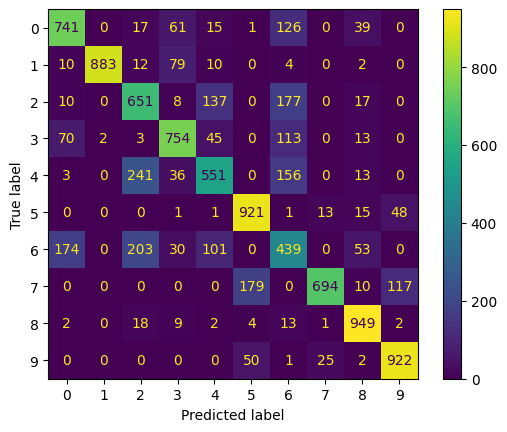

(0.7505, 0.7579843695642052)


In [226]:
mah_nc = NearestCentroid(n_subclasses=1,metric='mahalanobis')
mah_nc.fit(x_train_transformed,y_train)
y_pred_mah = mah_nc.predict(x_test_transformed)
print(evaluation(y_pred_mah,y_test))

 Accuracy Score: 0.6566
 Recall per class: [0.676 0.879 0.399 0.738 0.517 0.758 0.191 0.812 0.731 0.865]
 Precision per class: [0.68490375 0.9669967  0.46830986 0.67706422 0.48544601 0.48065948
 0.30126183 0.74769797 0.92648923 0.85558853]
 Macro Precision: 0.659441757410839


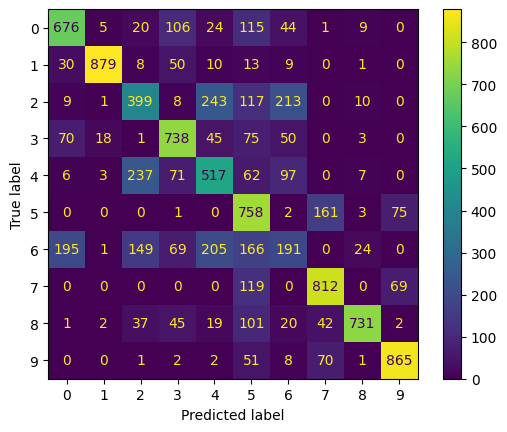

(0.6566, 0.659441757410839)


In [227]:
mah_eucl = NearestCentroid(n_subclasses=1,metric='euclidean')
mah_eucl.fit(x_train_transformed,y_train)
y_pred_euc = mah_eucl.predict(x_test_transformed)
print(evaluation(y_pred_euc,y_test))

## Mahalanobis Centroid Classifier using 2 subclass

 Accuracy Score: 0.7517
 Recall per class: [0.76  0.892 0.661 0.732 0.46  0.934 0.463 0.809 0.95  0.856]
 Precision per class: [0.74146341 0.99888018 0.56303237 0.79392625 0.58375635 0.81006071
 0.41155556 0.90391061 0.8644222  0.92440605]
 Macro Precision: 0.7595413685031308


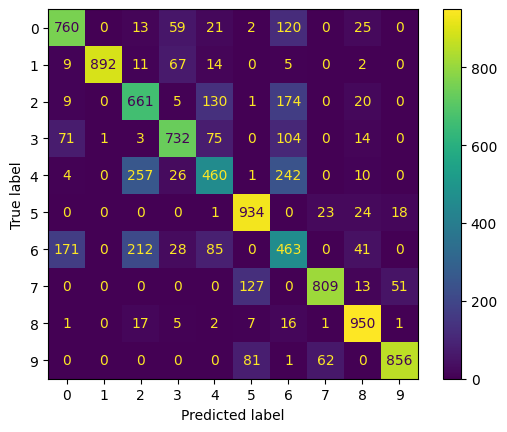

(0.7517, 0.7595413685031308)


In [228]:
mah_nc2 = NearestCentroid(n_subclasses=2,metric='mahalanobis')
mah_nc2.fit(x_train_transformed,y_train)
y_pred_mah2 = mah_nc2.predict(x_test_transformed)
print(evaluation(y_pred_mah2,y_test))

 Accuracy Score: 0.6906
 Recall per class: [0.76  0.879 0.584 0.785 0.453 0.81  0.215 0.811 0.775 0.834]
 Precision per class: [0.68345324 0.98322148 0.47518308 0.70720721 0.47089397 0.72192513
 0.29452055 0.75162187 0.93712213 0.89197861]
 Macro Precision: 0.691712725923123


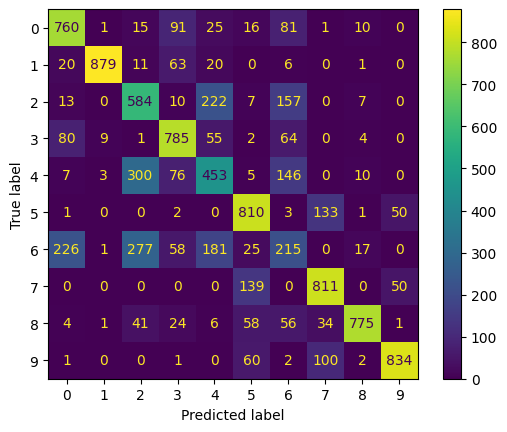

(0.6906, 0.691712725923123)


In [229]:
mah_eucl2 = NearestCentroid(n_subclasses=2,metric='euclidean')
mah_eucl2.fit(x_train_transformed,y_train)
y_pred_euc2 = mah_eucl2.predict(x_test_transformed)
print(evaluation(y_pred_euc2,y_test))

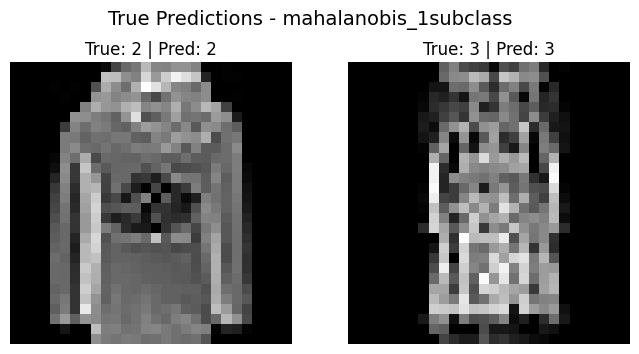

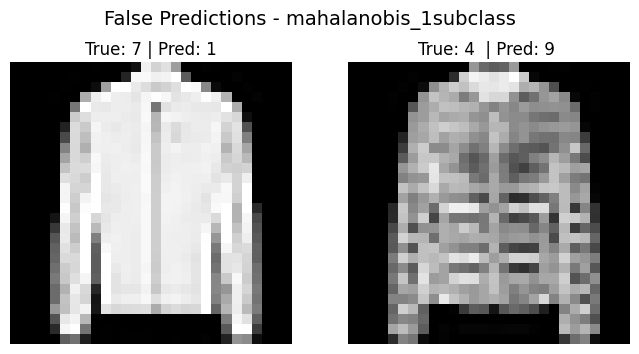

In [230]:
plot_and_save_analysis(y_test,y_pred_mah,x_test,"mahalanobis_1subclass")

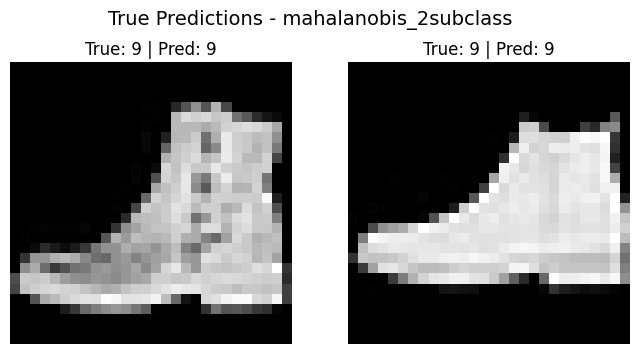

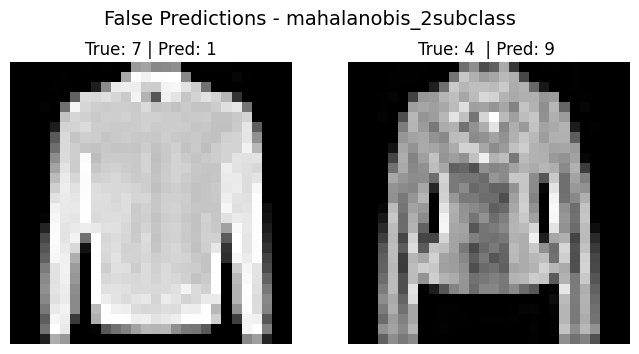

In [231]:
plot_and_save_analysis(y_test,y_pred_mah2,x_test,"mahalanobis_2subclass")

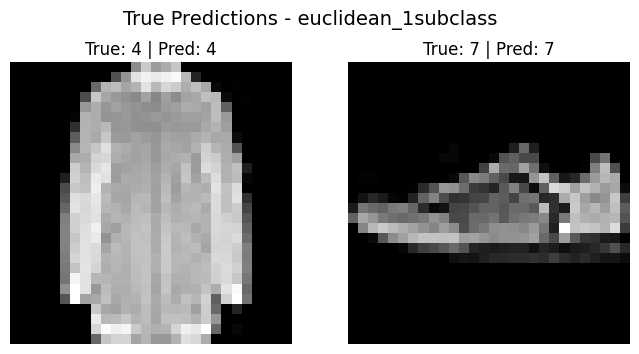

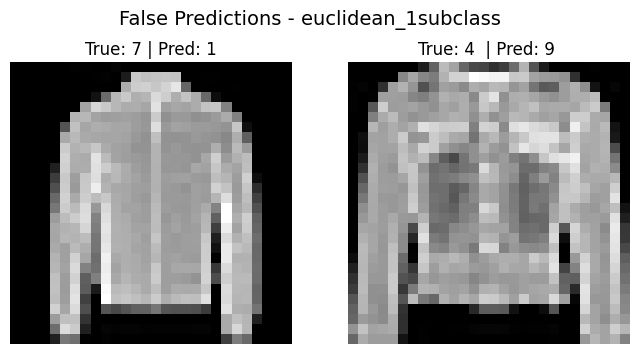

In [232]:
plot_and_save_analysis(y_test,y_pred_euc,x_test,"euclidean_1subclass")

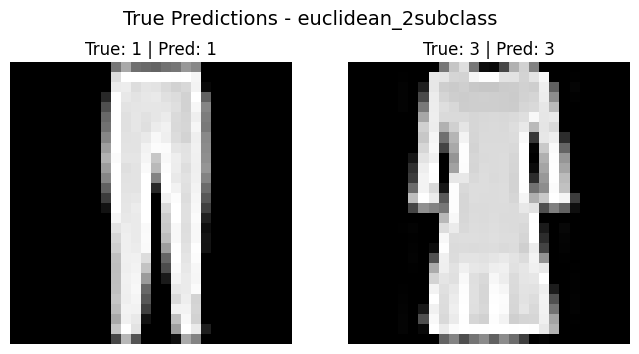

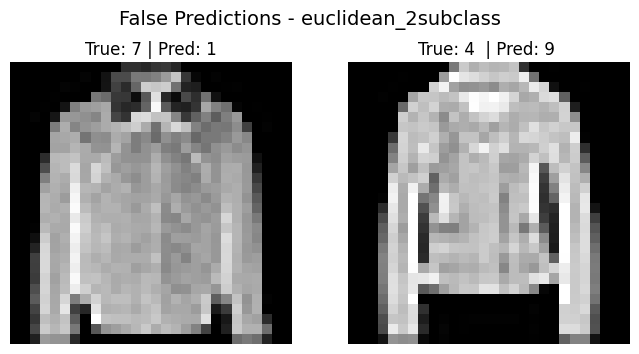

In [233]:
plot_and_save_analysis(y_test,y_pred_euc,x_test,"euclidean_2subclass")